1\. Write a function that converts number representation, bin<->dec<->hex. (Clearly using the corresponding python built-in functions is not fair..)

In [82]:
def printf(strg):
    lst=''
    for i in strg:
        lst+=str(i)
    return lst

def conversionbindec(strg):
    dec=0
    power=0
    for i in reversed(strg):
        if i=='1':
            dec+=2**power
        power+=1
    print(f'The binary {strg} in decimal notation is {dec}')

def conversiondecbin(strg):
    og=strg
    bin=[]
    binary_string=''
    while strg!=0:
        bin.append(strg%2)
        strg=strg//2
    bin=list(reversed(bin))
    print(f'The decimal {og} in binary notation is {printf(bin)}')

def conversiongen(strg):
    if isinstance(strg,str):
        conversionbindec(strg)
    else:
        conversiondecbin(strg)

conversiongen('110101')

The binary 110101 in decimal notation is 53


2\. Write a function that converts a 32 bit word into a single precision floating point (i.e. interprets the various bits as sign, mantissa and exponent)

In [61]:
def bitconverter(string):
    while len(string)<32:
        string='0'+string
    sign=string[0]
    if sign=='1':
        sign=-1
    else:
        sign=1
    exponent=string[1:9]
    exponent=2**(int(exponent,2)-127)
    mantissanum=0
    mantissa=string[9:]
    for i in range(len(mantissa)):
        mantissanum+=1/(2**(i+1))*int(mantissa[i])
    mantissa=mantissanum+1
    return sign*exponent*mantissa

floating_point=bitconverter('101101010100101010010110')
print(floating_point)


1.6648981197474227e-38


3\. Write a program to determine the underflow and overflow limits (within a factor of 2) for python on your computer. 

**Tips**: define two variables inizialized to 1 and halve/double them enough time to exceed the under/over-flow limits  

In [ ]:
#done easily

4\. Write a program to determine the machine precision

**Tips**: define a new variable by adding a smaller and smaller value (proceeding similarly to prob. 2) to an original variable and check the point where the two are the same 

In [9]:
i=1
val=1
val_aux=1.1
while val!=val_aux:
    val=1
    val_aux=1   
    add=1/(2**i)
    i+=1
    val_aux=1+add
print(i)
print(val)
print(val_aux)

54
1
1.0


5\. Write a function that takes in input three parameters $a$, $b$ and $c$ and prints out the two solutions to the quadratic equation $ax^2+bx+c=0$ using the standard formula:
$$
x=\frac{-b\pm\sqrt{b^2-4ac}}{2a}
$$

(a) use the program to compute the solution for $a=0.001$, $b=1000$ and $c=0.001$

(b) re-express the standard solution formula by multiplying top and bottom by $-b\mp\sqrt{b^2-4ac}$ and again find the solution for $a=0.001$, $b=1000$ and $c=0.001$. How does it compare with what previously obtained? Why?

(c) write a function that compute the roots of a quadratic equation accurately in all cases

In [ ]:
#catastrophic cancellation problem, easy

6\. Write a program that implements the function $f(x)=x(x−1)$

(a) Calculate the derivative of the function at the point $x = 1$ using the derivative definition:

$$
\frac{{\rm d}f}{{\rm d}x} = \lim_{\delta\to0} \frac{f(x+\delta)-f(x)}{\delta}
$$

with $\delta = 10^{−2}$. Calculate the true value of the same derivative analytically and compare with the answer your program gives. The two will not agree perfectly. Why not?

(b) Repeat the calculation for $\delta = 10^{−4}, 10^{−6}, 10^{−8}, 10^{−10}, 10^{−12}$ and $10^{−14}$. How does the accuracy scales with $\delta$?

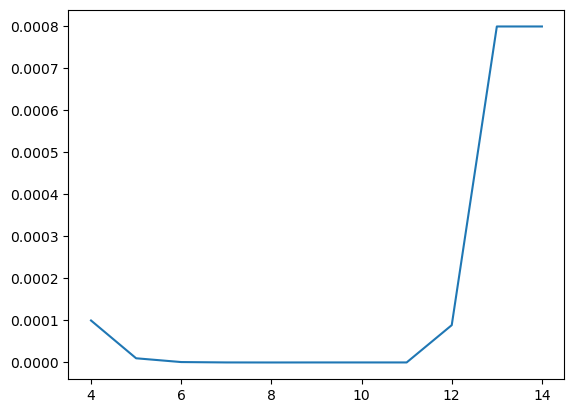

In [3]:
import numpy as np
import matplotlib.pyplot as plt
def func(x):
    return x*(x-1)
#a
delta=10**(-5)
deltas=np.arange(4,15)
derivatives=(func(1+pow(10.0,-1*deltas))-func(1.0))/pow(10.0,-1*deltas)

plt.plot(deltas,abs((derivatives-1.0)/derivatives))



7\. Consider the integral of the semicircle of radius 1:
$$
I=\int_{-1}^{1} \sqrt(1-x^2) {\rm d}x
$$
which it's known to be $I=\frac{\pi}{2}=1.57079632679...$.
Alternatively we can use the Riemann definition of the integral:
$$
I=\lim_{N\to\infty} \sum_{k=1}^{N} h y_k 
$$

with $h=2/N$ the width of each of the $N$ slices the domain is divided into and where
$y_k$ is the value of the function at the $k-$th slice.

(a) Write a programe to compute the integral with $N=100$. How does the result compares to the true value?

(b) How much can $N$ be increased if the computation needs to be run in less than a second? What is the gain in running it for 1 minute? 


In [4]:
def func(x):
    return np.sqrt(1-x**2)

def integral(N):
    I=0.0
    integration_range=np.linspace(-1,1,N)
    for i in range(N):
        I+=(2/N)*func(integration_range[i])
    return I
print(integral(10000000))

1.5707961696626787
